# NER

In [1]:
#Imports
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from itertools import combinations
from fuzzywuzzy import fuzz
from wordcloud import WordCloud
import networkx as nx
nlp = spacy.load("nl_core_news_lg")


c:\Users\joly-\Github\HUMAN\.venv312\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [6]:
#Load the dataframe
df = pd.read_csv('../data/subs_labelled_mapped.csv', index_col=0) #use the .pkl file for this script!
df.head()

,program,year,text_clean,ai_related,matched_keywords_all,relevant_section,processed,nouns,adjectives,verbs,topic,probability,topic_norm,topic_label,topic_meta
0,de wereld draait door,2016,"Eelco Bosch van Rosenthal, Dirk Jan Roeleven, ...",yes,"['facebook', 'google', 'twitter', 'algoritme']",...uit Amerika.\nVanochtend geland.\nHet Ameri...,documentaire voetspor undateables seizoen rufu...,documentaire voetspor undateables seizoen rufu...,mooi lang nieuw nepnieuws ander voorafgaand Am...,landen zien maken hebben zeggen willen tegenga...,6,0.102652,6,journalism and media,"MEDIA, ARTS, CULTURE & SPORTS"
1,jinek,2016,Uitzending bijwonen? Dat kan. Ga naar jinek.kr...,yes,['drones'],...over.\nEn onze tennisdames verrasten de wer...,tennisdame wereld baan klap sensatie nieuws po...,tennisdame wereld baan klap sensatie nieuws po...,regelrecht ander vorig Nederlands internationa...,verrasten meppen beslissen winnen bekennen opl...,0,0.136302,0,war and politics,AI WARFARE & MILIRTARY CONFLICTS
2,goedemorgen nederland,2023,en Joodse scholen die hun deuren vandaag dicht...,yes,"['ai', 'kunstmatige intelligentie']",...en de neus van de politie.\nWeet u hoe een ...,neus politie drugslab mens aanraking drug init...,neus politie drugslab mens aanraking drug init...,goed bewuster kunstmatig welmoed hoog laag dir...,weten werken weten denken komen vinden maken z...,19,1.000000,19,health and science,SCIENCE & HEALTH
3,goedemorgen nederland,2022,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,"['twitter', 'kunstmatige intelligentie']",...zegt de Britse minister van buitenlandse za...,minister zaak aanval aanval gemeenschap aanval...,minister zaak aanval aanval gemeenschap aanval...,Brits buitenlands roekeloos serieus internatio...,zeggen zeggen nemen doen nemen doen veroordele...,1,0.099202,1,public discourse and societal trends,SOCIETY
4,goedemorgen nederland,2020,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,['drone'],...er aardig uit.\nIs het een quarantainecoup?...,quarantainecoup filmp laag respect kappersvak ...,quarantainecoup filmp laag respect kappersvak ...,aardig diep moeilijk heel vast flink droog fli...,gekeken proberen opkrijgen doen nemen willen b...,5,1.000000,5,film industry,"MEDIA, ARTS, CULTURE & SPORTS"


In [7]:
# Function to retrieve entities
def extract_entities(text, nlp, similarity_threshold=90):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        if ent.label_ in ('PERSON'):
            entity_text = ent.text

            # Check if the new entity is a near duplicate of any of the entities already in the list
            if not any(fuzz.ratio(entity_text, entity) > similarity_threshold for entity in entities):
                entities.append(entity_text)
    return entities

In [13]:
# Function to get top entities for each publication type
def get_top_entities_for_category(df, publication_type, nlp, top_n=100):
    texts = df[df['program'] == publication_type]['relevant_section']
    all_entities = []
    for text in texts:
        all_entities.extend(extract_entities(text, nlp))
    return Counter(all_entities).most_common(top_n)

# Function to build the graph
def build_extended_graph(top_entities_by_publication_type):
    G = nx.Graph()
    
    # Add edges between publication types and entities
    for ptype in top_entities_by_publication_type:
        for entity, count in top_entities_by_publication_type[ptype]:
            G.add_edge(ptype, entity, weight=count)
    
    return G


In [14]:
# Extract the top 100 entities for each publication type, you can change this number
unique_publication_types = df['program'].unique()
top_entities_by_publication_type = {
    ptype: get_top_entities_for_category(df, ptype, nlp, top_n=100) 
    for ptype in unique_publication_types
}

# Build and save the graph
G = build_extended_graph(top_entities_by_publication_type)
nx.write_gexf(G, "shared_and_unique_entities.gexf")


In [17]:
def get_top_entities(df, nlp, text_col='relevant_section', top_n=20):
    """
    Iterate through df[text_col], extract entities, and return the top_n most common.
    """
    counter = Counter()
    # dropna() avoids errors if some bodies are missing
    for doc in df[text_col].dropna():
        ents = extract_entities(doc, nlp)
        counter.update(ents)
    return counter.most_common(top_n)


In [18]:
top_20 = get_top_entities(df, nlp)
print(top_20)


[('Trump', 26), ('Rutte', 15), ('Donald Trump', 14), ('Alexander Klöpping', 14), ('Maaike', 14), ('Geert Wilders', 14), ('Jill', 13), ('Sven Kockelmann', 13), ('Alexander', 12), ('Frank', 10), ('dank', 10), ('Welmoed', 9), ('Mark Rutte', 8), ('Poetin', 7), ('Wouter', 7), ('Rick Nieman', 7), ('Linda', 7), ('Mark Zuckerberg', 7), ('Jean Dohmen', 7), ('Maaike Timmerman', 7)]


In [19]:
def plot_bar_chart(entities, title):
    """
    entities: list of (label, count)
    title:   string for the plot title
    """
    labels, values = zip(*entities) if entities else ([], [])
    plt.figure(figsize=(10, 5))
    plt.bar(labels, values, color='skyblue')
    plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

def plot_word_cloud(entities, title):
    """
    entities: list of (label, count)
    title:    string for the plot title
    """
    freqs = {label: count for label, count in entities}
    wordcloud = WordCloud(
        width=800, height=400, background_color='white'
    ).generate_from_frequencies(freqs)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


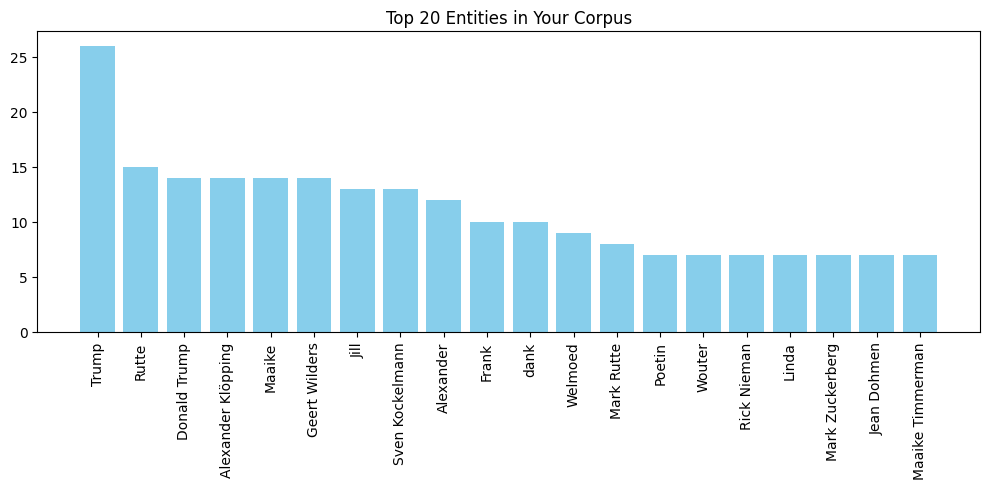

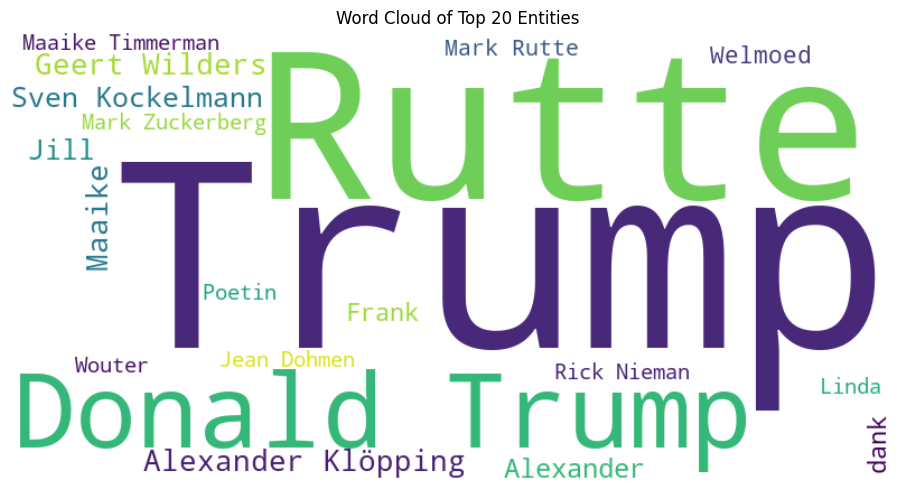

In [20]:
# --- Example usage with your get_top_entities() ---
#stop_20 = get_top_entities(df, nlp, text_col='body', top_n=20)

#Plot both views in one go:
plot_bar_chart(top_20, 'Top 20 Entities in Your Corpus')
plot_word_cloud(top_20, 'Word Cloud of Top 20 Entities')


In [21]:
top_20

[('Trump', 26),
 ('Rutte', 15),
 ('Donald Trump', 14),
 ('Alexander Klöpping', 14),
 ('Maaike', 14),
 ('Geert Wilders', 14),
 ('Jill', 13),
 ('Sven Kockelmann', 13),
 ('Alexander', 12),
 ('Frank', 10),
 ('dank', 10),
 ('Welmoed', 9),
 ('Mark Rutte', 8),
 ('Poetin', 7),
 ('Wouter', 7),
 ('Rick Nieman', 7),
 ('Linda', 7),
 ('Mark Zuckerberg', 7),
 ('Jean Dohmen', 7),
 ('Maaike Timmerman', 7)]

In [23]:
# --- 1) Remove items that are clearly not people ---
non_persons = {'August', 'God', 'Al', 'Oranje', 'Trouw', 'May', 'Amazon', 'Huawei', 'Tesla', 'Albert Heijn', 'dank'}

filtered = [(name, count) for name, count in top_20 if name not in non_persons]

# --- 2) Define merge mapping for duplicates / variants ---
merge_map = {
    'Maaike': 'Maaike Timmerman',
    'Rutte': 'Mark Rutte',
    'Mark Rutte': 'Mark Rutte',
    'Wilders': 'Geert Wilders',
    'Geert Wilders': 'Geert Wilders',
    'Trump': 'Donald Trump',
    'Donald Trump': 'Donald Trump',
    'Merkel': 'Angela Merkel',
    'Angela Merkel': 'Angela Merkel',
    'Van der Burg': 'Eric van der Burg',
    'Eric van der Burg': 'Eric van der Burg',
    'Altman': 'Sam Altman',
    'Sam Altman': 'Sam Altman',
    'Elon': 'Elon Musk', 
    
    # Others can stay as is
}

# --- 3) Merge counts based on canonical name ---
merged = defaultdict(int)
for name, count in filtered:
    canonical = merge_map.get(name, name)
    merged[canonical] += count

# --- 4) Sort by frequency descending ---
cleaned_top = sorted(merged.items(), key=lambda x: x[1], reverse=True)

# --- 5) Print result ---
for name, count in cleaned_top:
    print(f"{name}: {count}")


Donald Trump: 40
Mark Rutte: 23
Maaike Timmerman: 21
Alexander Klöpping: 14
Geert Wilders: 14
Jill: 13
Sven Kockelmann: 13
Alexander: 12
Frank: 10
Welmoed: 9
Poetin: 7
Wouter: 7
Rick Nieman: 7
Linda: 7
Mark Zuckerberg: 7
Jean Dohmen: 7


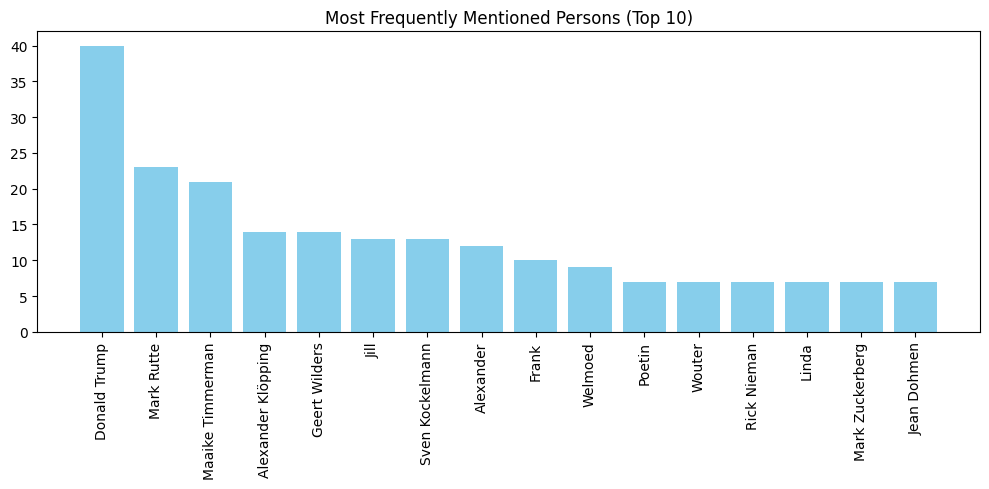

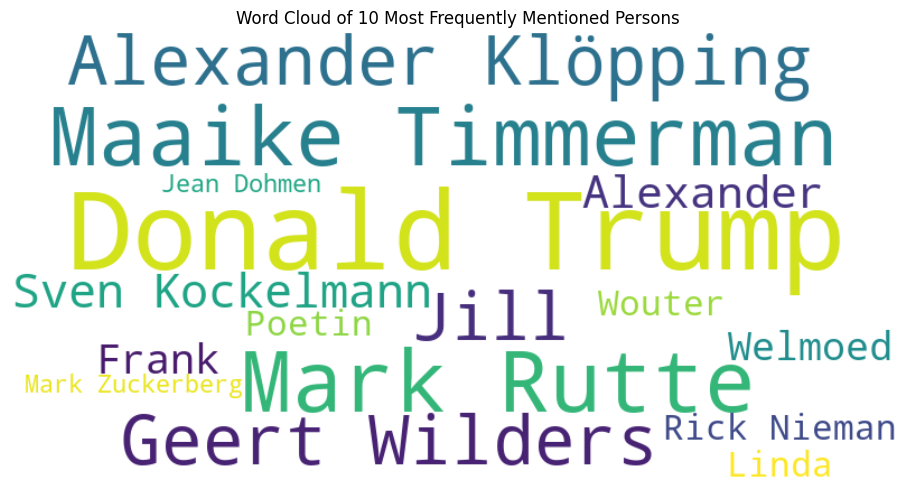

In [24]:

# --- Example usage with your get_top_entities() ---
#stop_20 = get_top_entities(df, nlp, text_col='body', top_n=20)

#Plot both views in one go:
plot_bar_chart(cleaned_top, 'Most Frequently Mentioned Persons (Top 10)')
plot_word_cloud(cleaned_top, 'Word Cloud of 10 Most Frequently Mentioned Persons')


In [13]:
df

,title,outlet,date,authors,body,word_count,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,...,date_parsed,year,topic,probability,topic_norm,topic_label_nl,topic_meta_nl,topic_label,topic_meta,ai_words
0,Chatbot Emma glimlacht na een compliment Chatb...,Parool,2015-10-23,BART VAN ZOELEN,"'Dag Denise, hoe oud ben jij?"" vragen we Denis...",238,yes,['chatbot'],['chatbots'],"['chatbot', 'chatbots']",...,2015-10-23,2015,8,0.153558,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
1,Vera en Roos hebben het druk Vera en Roos hebb...,Parool,2015-10-23,BART VAN ZOELEN,Klantenservice: Virtuele medewerkers kunnen st...,249,yes,[],"['chatbot', 'chatbots']","['chatbot', 'chatbots']",...,2015-10-23,2015,8,0.212454,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
2,Leer van big data-incidenten Leer van big data...,Parool,2015-01-03,Unknown Authors,Keerpunt: De doorbraak van big data \nBracht 2...,303,yes,[],['slimme algoritmes'],['slimme algoritmes'],...,2015-01-03,2015,12,0.128177,12,bitcoin,BEDRIJF & FINANCIËN,bitcoin,BUSINESS & FINANCE,[]
3,Brieven Brieven,Parool,2015-09-03,Unknown Authors,Geen vrije keuze \nVrijdag had Het Parool een ...,310,yes,[],['algoritme'],['algoritme'],...,2015-09-03,2015,14,0.373948,14,onderwijs,ONDERWIJS,eductation,EDUCATION,[]
4,Stad van stenen en pixels Stad van stenen en p...,Parool,2015-05-19,TRACY METZ,"De talkshow Stadsleven, deze maand tegelijk me...",317,yes,[],['algoritme'],['algoritme'],...,2015-05-19,2015,8,1.000000,8,facebook en algoritmen,SOCIALE MEDIA,facebook and algorithms,SOCIAL MEDIA,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13204,De nieuwe versie van ChatGPT blundert als vano...,VK,2025-08-12,LAURENS VERHAGEN,1.\nOpenAI maakt de hype niet waar\nToen OpenA...,207,yes,['chatgpt'],"['ai', 'chatgpt', 'generatieve ai', 'gpt', 'op...","['ai', 'chatgpt', 'generatieve ai', 'gpt', 'op...",...,2025-08-12,2025,19,0.055403,19,AI-modellen,TECH & AI ONTWIKKELING,AI models,TECH & AI DEVELOPMENT,[]
13205,Een superbrein dat de mens voorbijstreeft? Een...,VK,2025-06-07,LAURENS VERHAGEN,Technologie 'Denkende' en 'begrijpende' AI\n'C...,297,yes,[],"['ai', 'anthropic', 'chatgpt', 'deepmind', 'll...","['ai', 'anthropic', 'chatgpt', 'deepmind', 'll...",...,2025-06-07,2025,16,0.037080,16,chatbots en desinformatie,AI RISICO'S & ETHIEK,chatbots and desinformation,AI RISKS & ETHICS,[]
13206,Grote AI-denker bleef gefascineerd door de men...,VK,2025-08-22,LAURENS VERHAGEN,Margaret Boden (1936-2025)\nIs het geheel nieu...,255,yes,['ai'],"['ai', 'chatgpt', 'kunstmatige intelligentie']","['ai', 'chatgpt', 'kunstmatige intelligentie']",...,2025-08-22,2025,15,0.008852,15,AI en tech trends,TECH & AI ONTWIKKELING,AI and tech trends,TECH & AI DEVELOPMENT,[]
13207,De 'nerdy' miljardair achter DeepSeek De 'nerd...,VK,2025-01-29,FRANK RENSEN,Liang Wenfeng\nUit het niets verscheen de AI-a...,278,yes,[],"['ai', 'chatbot', 'chatgpt', 'openai']","['ai', 'chatbot', 'chatgpt', 'openai']",...,2025-01-29,2025,1,0.033187,1,chipindustrie,AI INFRASTRUCTUUR & CHIPINDUSTRIE,chip industry,AI INFRASTRUCTURE & CHIP INDUSTRY,[]


In [26]:
# 2) Define a helper that returns the 3 lists for one text
def get_entities_by_type(text, nlp):
    doc = nlp(text or "")
    persons   = list({ent.text for ent in doc.ents if ent.label_ == 'PERSON'})
    orgs      = list({ent.text for ent in doc.ents if ent.label_ == 'ORG'})
    countries = list({ent.text for ent in doc.ents if ent.label_ == 'GPE'})
    return persons, orgs, countries

# 3) Apply it to every row and expand into 3 new columns
df[['persons', 'orgs', 'countries']] = (
    df['relevant_section']
      .fillna("")  # avoid passing NaN into the nlp pipeline
      .map(lambda txt: get_entities_by_type(txt, nlp)) 
      .apply(pd.Series)  # turns each (persons, orgs, countries) tuple into 3 columns
)   

In [27]:
df.head()

,program,year,text_clean,ai_related,matched_keywords_all,relevant_section,processed,nouns,adjectives,verbs,topic,probability,topic_norm,topic_label,topic_meta,persons,orgs,countries
0,de wereld draait door,2016,"Eelco Bosch van Rosenthal, Dirk Jan Roeleven, ...",yes,"['facebook', 'google', 'twitter', 'algoritme']",...uit Amerika.\nVanochtend geland.\nHet Ameri...,documentaire voetspor undateables seizoen rufu...,documentaire voetspor undateables seizoen rufu...,mooi lang nieuw nepnieuws ander voorafgaand Am...,landen zien maken hebben zeggen willen tegenga...,6,0.102652,6,journalism and media,"MEDIA, ARTS, CULTURE & SPORTS","[Noah Trebble, Dirk Jan Roeleven, Nico, Trump,...","[Google, VARA, Mama Appelsap, Muppets]","[Amerika, New YorkTimes, Amsterdam, New York]"
1,jinek,2016,Uitzending bijwonen? Dat kan. Ga naar jinek.kr...,yes,['drones'],...over.\nEn onze tennisdames verrasten de wer...,tennisdame wereld baan klap sensatie nieuws po...,tennisdame wereld baan klap sensatie nieuws po...,regelrecht ander vorig Nederlands internationa...,verrasten meppen beslissen winnen bekennen opl...,0,0.136302,0,war and politics,AI WARFARE & MILIRTARY CONFLICTS,"[al., Kiki Bertens, Beyonce, Bruno Mars, Kuzne...",[UPTOWN],"[Rusland, Moskou]"
2,goedemorgen nederland,2023,en Joodse scholen die hun deuren vandaag dicht...,yes,"['ai', 'kunstmatige intelligentie']",...en de neus van de politie.\nWeet u hoe een ...,neus politie drugslab mens aanraking drug init...,neus politie drugslab mens aanraking drug init...,goed bewuster kunstmatig welmoed hoog laag dir...,weten werken weten denken komen vinden maken z...,19,1.000000,19,health and science,SCIENCE & HEALTH,"[Frank, Welmoed]","[Stowell, Dagblad Trouw, AI]",[]
3,goedemorgen nederland,2022,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,"['twitter', 'kunstmatige intelligentie']",...zegt de Britse minister van buitenlandse za...,minister zaak aanval aanval gemeenschap aanval...,minister zaak aanval aanval gemeenschap aanval...,Brits buitenlands roekeloos serieus internatio...,zeggen zeggen nemen doen nemen doen veroordele...,1,0.099202,1,public discourse and societal trends,SOCIETY,"[Johnson, Timmermans, Marije]",[],[Wierd]
4,goedemorgen nederland,2020,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,['drone'],...er aardig uit.\nIs het een quarantainecoup?...,quarantainecoup filmp laag respect kappersvak ...,quarantainecoup filmp laag respect kappersvak ...,aardig diep moeilijk heel vast flink droog fli...,gekeken proberen opkrijgen doen nemen willen b...,5,1.000000,5,film industry,"MEDIA, ARTS, CULTURE & SPORTS",[],[],"[België, Zwolle]"


In [28]:
df.to_csv('subs_with_NER.csv')